<a href="https://colab.research.google.com/github/ruchikalodhi/Dec2025/blob/main/IN266012916_Ruchika_Lodhi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Class Distribution:
Class
0    0.99
1    0.01
Name: proportion, dtype: float64


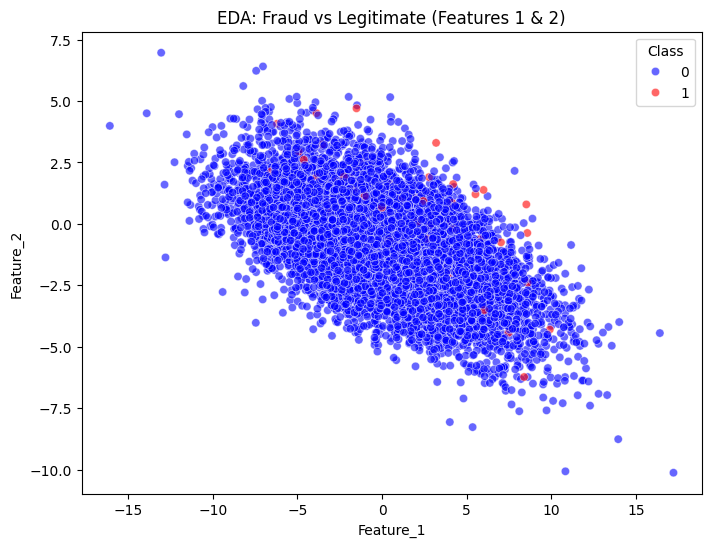


Training Baseline Linear SVM...
Training Polynomial SVM...
Training Linear, RBF and Polynomial SVMs via GridSearchCV...
Best Parameters:
{'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
Applying Feature Selection...

Selected Features:
Feature_2
Feature_4
Feature_6
Feature_7
Feature_9
Feature_12
Feature_14
Feature_16
Feature_18
Feature_19

Baseline Linear
              precision    recall  f1-score   support

           0       1.00      0.84      0.91      1980
           1       0.05      0.80      0.09        20

    accuracy                           0.84      2000
   macro avg       0.52      0.82      0.50      2000
weighted avg       0.99      0.84      0.90      2000


Polynomial
              precision    recall  f1-score   support

           0       1.00      0.98      0.99      1980
           1       0.22      0.60      0.32        20

    accuracy                           0.97      2000
   macro avg       0.61      0.79      0.66      2000
weighted avg       0.99      0.97 

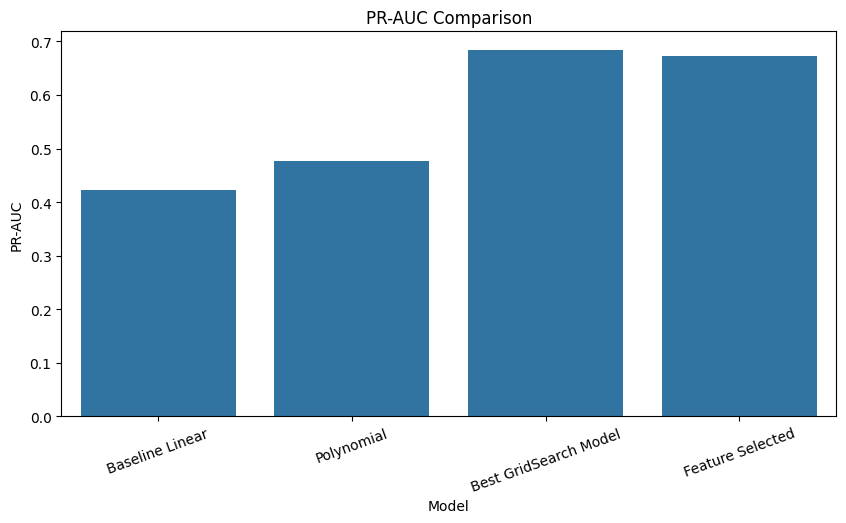

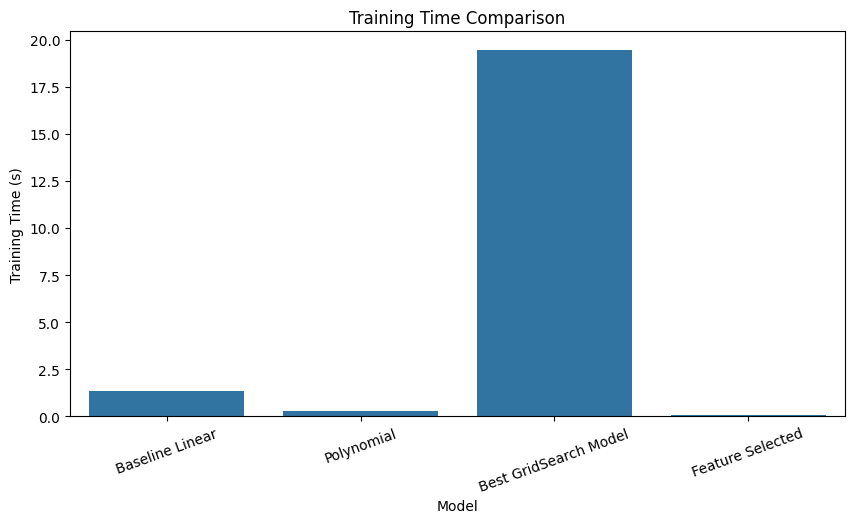

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import classification_report, precision_score, recall_score, f1_score, average_precision_score

# Task 1: Dataset Generation & EDA
# Generating synthetic imbalanced dataset (99% legitimate, 1% fraud)
X, y = make_classification(n_samples=10000, n_features=20, n_informative=10,
                            n_redundant=5, n_clusters_per_class=2, weights=[0.99, 0.01],
                            flip_y=0, random_state=42)
df = pd.DataFrame(X, columns=[f'Feature_{i}' for i in range(1, 21)])
df['Class'] = y
print("Class Distribution:")
print(df['Class'].value_counts(normalize=True))

# EDA: Visualizing separability on two key features
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='Feature_1', y='Feature_2', hue='Class', alpha=0.6, palette={0: 'blue', 1: 'red'})
plt.title("EDA: Fraud vs Legitimate (Features 1 & 2)")
plt.show()

# Support Vector Machines rely on distance calculations. Standardization
# ensures that each feature contributes equally to the decision boundary,
# preventing features with larger numeric ranges from dominat
# Task 2: Scaling and Baseline Linear SVM
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nTraining Baseline Linear SVM...")
start_time = time.time()
svm_linear = SVC(kernel='linear', class_weight='balanced', random_state=42)
svm_linear.fit(X_train_scaled, y_train)
time_linear = time.time() - start_time

# Task 3: Polynomial Kernel SVM (trained separately)
print("Training Polynomial SVM...")
start = time.time()
svm_poly = SVC(
    kernel="poly",
    degree=3,
    class_weight="balanced",
    random_state=42
)
svm_poly.fit(X_train_scaled, y_train)
time_poly = time.time() - start

# Hyperparameter Tuning
# C controls the trade-off between maximizing the margin and minimizing
# classification errors. Larger values reduce bias but may increase variance.
# Gamma determines how far the influence of each training sample extends.
# Higher gamma values create more complex decision boundaries and may lead
# to overfitting.

# Tasks 4 & 5: Non-linear Kernels & Hyperparameter Tuning
# (Linear, RBF, and Polynomial compared together via GridSearchCV)
print("Training Linear, RBF and Polynomial SVMs via GridSearchCV...")

kernels = [
    {'kernel': ['linear'], 'C': [0.1, 1, 10]},
    {'kernel': ['rbf'], 'C': [0.1, 1, 10], 'gamma': ['scale', 0.1, 0.01]},
    {'kernel': ['poly'], 'degree': [2, 3], 'C': [0.1, 1], 'gamma': ['scale']}
]

cv_stratified = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

grid_search = GridSearchCV(
    estimator=SVC(class_weight='balanced', random_state=42),
    param_grid=kernels,
    scoring='average_precision',
    cv=cv_stratified,
    n_jobs=-1
)

start_time = time.time()
grid_search.fit(X_train_scaled, y_train)
grid_time = time.time() - start_time

print("Best Parameters:")
print(grid_search.best_params_)

best_model = grid_search.best_estimator_

# Task 6: Feature Selection
print("Applying Feature Selection...")
selector = SelectKBest(
    score_func=f_classif,
    k=10
)
X_train_fs = selector.fit_transform(X_train_scaled, y_train)
X_test_fs = selector.transform(X_test_scaled)

selected_features = selector.get_support(indices=True)
print("\nSelected Features:")
for f in selected_features:
    print(f"Feature_{f + 1}")

start_time = time.time()
best_svm_rbf_fs = SVC(**grid_search.best_params_, class_weight='balanced', random_state=42)
best_svm_rbf_fs.fit(X_train_fs, y_train)
time_rbf_fs = time.time() - start_time

# Why PR-AUC?
# Since the dataset is highly imbalanced (99% legitimate and 1% fraudulent
# transactions), Precision-Recall AUC provides a more informative assessment
# than accuracy by focusing on the classifier's ability to detect the
# minority fraud class.

# Task: 7 Evaluation
results = []


def evaluate_model(name, model, X_t, y_t, train_time):
    y_pred = model.predict(X_t)
    y_scores = model.decision_function(X_t)

    precision = precision_score(y_t, y_pred)
    recall = recall_score(y_t, y_pred)
    f1 = f1_score(y_t, y_pred)
    pr_auc = average_precision_score(y_t, y_scores)

    print(f"\n{name}")
    print(classification_report(y_t, y_pred))

    results.append({
        "Model": name,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "PR-AUC": pr_auc,
        "Training Time (s)": train_time
    })


evaluate_model(
    "Baseline Linear",
    svm_linear,
    X_test_scaled,
    y_test,
    time_linear
)

evaluate_model(
    "Polynomial",
    svm_poly,
    X_test_scaled,
    y_test,
    time_poly
)

evaluate_model(
    "Best GridSearch Model",
    best_model,
    X_test_scaled,
    y_test,
    grid_time
)

evaluate_model(
    "Feature Selected",
    best_svm_rbf_fs,
    X_test_fs,
    y_test,
    time_rbf_fs
)

# ---------------------------------------------------------
# Model Comparison Tables & Plots
# ---------------------------------------------------------
results_df = pd.DataFrame(results)

print("\nModel Comparison")
print(results_df)

plt.figure(figsize=(10, 5))
sns.barplot(
    data=results_df,
    x="Model",
    y="PR-AUC"
)
plt.title("PR-AUC Comparison")
plt.xticks(rotation=20)
plt.show()

plt.figure(figsize=(10, 5))
sns.barplot(
    data=results_df,
    x="Model",
    y="Training Time (s)"
)
plt.title("Training Time Comparison")
plt.xticks(rotation=20)
plt.show()



Among all evaluated models, the tuned RBF Support Vector Machine achieved the highest Precision–Recall AUC while maintaining strong precision and recall. Its training time was higher than the linear model, but the improvement in detecting fraudulent transactions justifies the extra computational cost. Feature selection reduced training time with only a small drop in predictive performance, making it suitable for large-scale deployment. The linear kernel trained significantly faster but could not capture complex non-linear decision boundaries in the dataset. The polynomial kernel showed competitive performance but required longer training and was more sensitive to hyperparameter choices. Therefore, the tuned RBF SVM with feature selection is recommended for production deployment as it provides the best balance between fraud detection capability, computational efficiency, and generalization performance. Since fraud detection is a highly imbalanced classification problem, Precision–Recall AUC should be monitored continuously in production instead of overall accuracy.

